In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
NUM_OBJECTS = len(OBJECTS)

In [4]:
print("Setup complete!")
print("Objects:", OBJECTS)

Setup complete!
Objects: ['cup', 'ball', 'book', 'phone', 'apple']


In [6]:
def create_sensory_input(true_object, num_columns, noise_level=0.3):
    """
    Creates evidence matrix for all columns.

    Parameters:
    - true_object: int, index of the actual object (0 to NUM_OBJECTS-1)
    - num_columns: int, number of cortical columns to simulate
    - noise_level: float, amount of random noise (0 to 1)

    Returns:
    - evidence: numpy array of shape (num_columns, NUM_OBJECTS)
    """

    # Number of objects comes from the setup cell
    NUM_OBJECTS = len(OBJECTS)

    # TODO 1: Create matrix filled with random noise
    # Shape: (num_columns, NUM_OBJECTS)
    evidence = np.random.uniform(
        low=0,
        high=noise_level,
        size=(num_columns, NUM_OBJECTS)
    )

    # TODO 2: Add stronger signal for the true object
    # Each column gets an added signal between 0.5 and 1.0
    for col in range(num_columns):
        signal = np.random.uniform(0.5, 1.0)
        evidence[col, true_object] += signal

    # TODO 3: Normalize each row so values sum to 1
    row_sums = evidence.sum(axis=1, keepdims=True)
    evidence = evidence / row_sums

    return evidence

In [8]:
# Test create_sensory_input
true_object = 0 # "cup"
num_columns = 6
evidence = create_sensory_input(true_object, num_columns, noise_level=0.3)
print(f"True object: {OBJECTS[true_object]}")
print(f"Evidence shape: {evidence.shape}")
print("\nEach column's evidence:")
for i in range(num_columns):
    best = OBJECTS[np.argmax(evidence[i])]
    conf = np.max(evidence[i]) * 100
    print(f" Column {i}: {best} ({conf:.1f}%)")

True object: cup
Evidence shape: (6, 5)

Each column's evidence:
 Column 0: cup (55.6%)
 Column 1: cup (48.5%)
 Column 2: cup (45.0%)
 Column 3: cup (68.9%)
 Column 4: cup (75.6%)
 Column 5: cup (73.7%)


In [10]:
def initialize_beliefs(evidence):
    """Initialize beliefs from sensory evidence."""
    return evidence.copy()


In [11]:
beliefs = initialize_beliefs(evidence)
print("Beliefs initialized!")
print(f"Shape: {beliefs.shape}")
print(f"Same as evidence? {np.allclose(beliefs, evidence)}")

Beliefs initialized!
Shape: (6, 5)
Same as evidence? True


In [12]:
def voting_round(beliefs, evidence, vote_weight=0.3):
    """
    One round of voting among columns.

    Parameters:
    - beliefs: current beliefs, shape (num_columns, NUM_OBJECTS)
    - evidence: original sensory evidence (doesn't change)
    - vote_weight: float 0-1, how much to trust neighbors

    Returns:
    - new_beliefs: updated beliefs after voting
    """

    num_columns = beliefs.shape[0]
    new_beliefs = np.zeros_like(beliefs)

    for col in range(num_columns):
        # TODO 1: Calculate this column's own contribution
        # (1 - vote_weight) * evidence[col]
        own_contribution = (1 - vote_weight) * evidence[col]

        # TODO 2: Get beliefs from OTHER columns (not this one)
        other_indices = [i for i in range(num_columns) if i != col]
        other_beliefs = beliefs[other_indices]

        # TODO 3: Calculate average vote from others
        # Mean across columns
        avg_vote = other_beliefs.mean(axis=0)

        # TODO 4: Calculate vote contribution
        vote_contribution = vote_weight * avg_vote

        # TODO 5: Combine own + vote contributions
        new_beliefs[col] = own_contribution + vote_contribution

    # TODO 6: Normalize rows so each sums to 1
    row_sums = new_beliefs.sum(axis=1, keepdims=True)
    new_beliefs = new_beliefs / row_sums

    return new_beliefs

In [14]:
print("Before voting:")
for i in range(3):
    print(f" Col {i}: {OBJECTS[np.argmax(beliefs[i])]}"
          f" ({np.max(beliefs[i]) * 100:.1f}%)")

new_beliefs = voting_round(beliefs, evidence, vote_weight=0.3)

print("\nAfter 1 voting round:")
for i in range(3):
    print(f" Col {i}: {OBJECTS[np.argmax(new_beliefs[i])]}"
          f" ({np.max(new_beliefs[i]) * 100:.1f}%)")


Before voting:
 Col 0: cup (55.6%)
 Col 1: cup (48.5%)
 Col 2: cup (45.0%)

After 1 voting round:
 Col 0: cup (57.6%)
 Col 1: cup (53.1%)
 Col 2: cup (50.8%)


In [15]:
def run_voting(evidence, max_iterations=20, vote_weight=0.3, consensus_threshold=0.9):
    """
    Run voting until consensus or max iterations.

    Returns: (history, final_object, final_confidence, iterations_used)
    """

    # TODO 1: Initialize beliefs
    beliefs = initialize_beliefs(evidence)

    # TODO 2: Start history list with initial beliefs
    history = [beliefs.copy()]

    for iteration in range(max_iterations):
        # TODO 3: Do one voting round
        beliefs = voting_round(beliefs, evidence, vote_weight)

        # TODO 4: Add to history
        history.append(beliefs.copy())

        # TODO 5: Check consensus
        predictions = np.argmax(beliefs, axis=1)
        vote_counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        most_common = vote_counts.argmax()
        agreement = (predictions == most_common).mean()

        # TODO 6: Break if consensus reached
        if agreement >= consensus_threshold:
            print(f"Consensus at iteration {iteration + 1}!")
            break

    # Calculate final result
    final_votes = beliefs.mean(axis=0)  # average across columns
    final_object = np.argmax(final_votes)
    final_confidence = final_votes[final_object]
    iterations_used = len(history) - 1

    return history, final_object, final_confidence, iterations_used


In [16]:
# Test run_voting
np.random.seed(42)
evidence = create_sensory_input(true_object=0, num_columns=6,
noise_level=0.3)
history, result, confidence, iters = run_voting(evidence)
print(f"Result: {OBJECTS[result]}")
print(f"Confidence: {confidence*100:.1f}%")
print(f"Iterations: {iters}")
print(f"Correct? {'Yes!' if result == 0 else 'No'}")

Consensus at iteration 1!
Result: cup
Confidence: 61.2%
Iterations: 1
Correct? Yes!


In [17]:
def visualize_consensus(history, true_object):
    """Visualize how consensus emerges."""

    # Average confidence per object at each iteration
    avg_confidence = np.array([h.mean(axis=0) for h in history])
    # Shape: (num_iterations, NUM_OBJECTS)

    # TODO 1: Calculate agreement at each time step
    agreement_over_time = []
    for h in history:
        predictions = np.argmax(h, axis=1)
        counts = np.bincount(predictions, minlength=NUM_OBJECTS)
        agreement = counts.max() / len(predictions)  # <-- TODO 1
        agreement_over_time.append(agreement)

    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot 1 - Confidence over time
    ax1 = axes[0]
    for obj_idx in range(NUM_OBJECTS):
        if obj_idx == true_object:
            style = '-'
            width = 3
        else:
            style = '--'
            width = 1
        ax1.plot(avg_confidence[:, obj_idx], style, linewidth=width, label=OBJECTS[obj_idx])

    ax1.set_xlabel('Voting Round')
    ax1.set_ylabel('Average Confidence')
    ax1.set_title('Confidence Evolution')
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    # Plot 2 - Agreement over time
    ax2 = axes[1]
    ax2.plot(agreement_over_time, 'b-', linewidth=2, marker='o')
    ax2.axhline(y=0.9, color='r', linestyle='--', label='Threshold')
    ax2.set_xlabel('Voting Round')
    ax2.set_ylabel('Column Agreement')
    ax2.set_title('Consensus Emergence')
    ax2.legend()
    ax2.set_ylim(0, 1.05)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('consensus_plot.png', dpi=150)
    plt.show()

    print("Plot saved as consensus_plot.png")


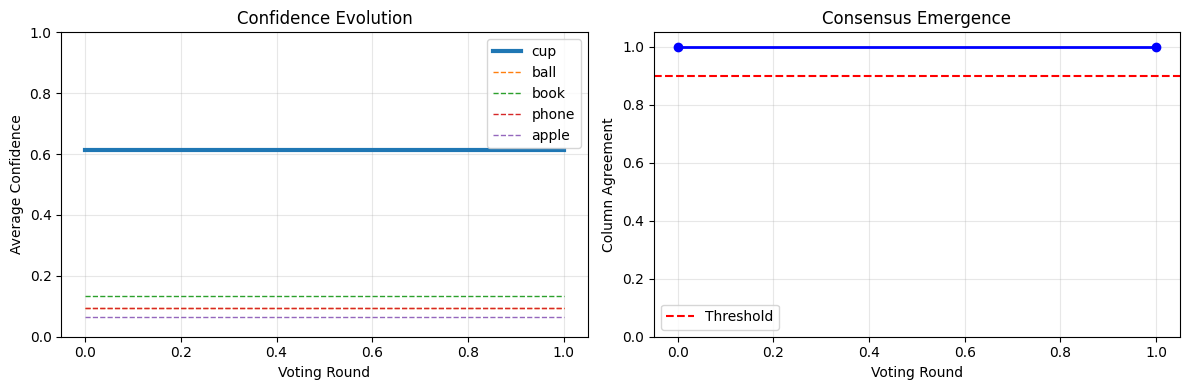

Plot saved as consensus_plot.png


In [18]:
# Create visualization
visualize_consensus(history, true_object=0)

EXPERIMENT 1: HIGH NOISE
Consensus at iteration 1!
Result: cup
Confidence: 42.3%
Iterations: 1
Correct? Yes


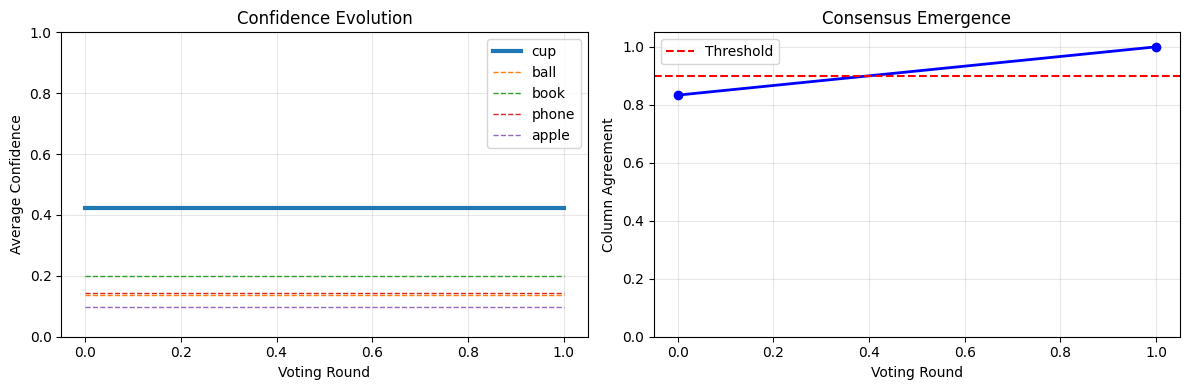

Plot saved as consensus_plot.png


In [20]:
# EXPERIMENT 1: High Noise
print("="*50)
print("EXPERIMENT 1: HIGH NOISE")
print("="*50)
np.random.seed(42) # Reset seed for fair comparison
evidence_noisy = create_sensory_input(
true_object=0,
num_columns=6,
noise_level=0.8 # <-- Changed from 0.3
)
history_noisy, result_noisy, conf_noisy, iters_noisy = run_voting(evidence_noisy)
print(f"Result: {OBJECTS[result_noisy]}")
print(f"Confidence: {conf_noisy*100:.1f}%")
print(f"Iterations: {iters_noisy}")
print(f"Correct? {'Yes' if result_noisy == 0 else 'NO - WRONG ANSWER'}")
# Visualize
visualize_consensus(history_noisy, true_object=0)

EXPERIMENT 2: MORE COLUMNS
Consensus at iteration 1!
Result: cup
Confidence: 62.8%
Iterations: 1

Comparison to original (6 columns):
 6 columns: 61.2% confidence
 20 columns: 62.8% confidence


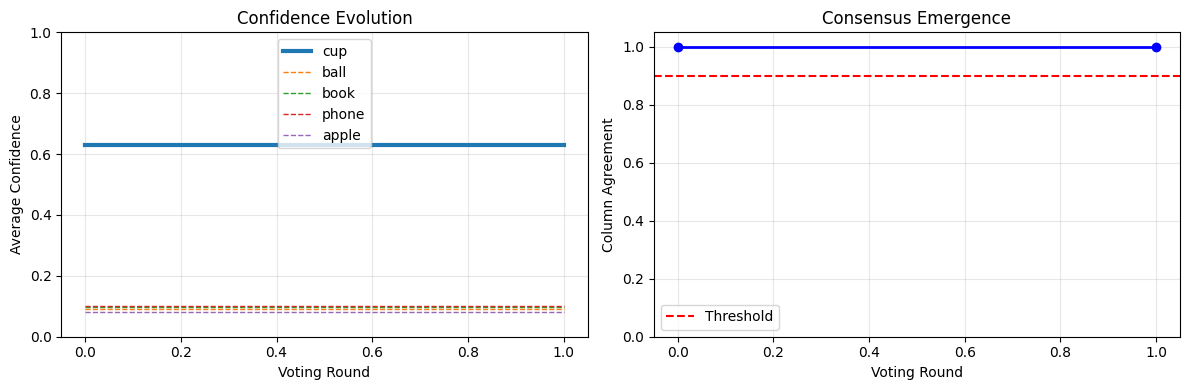

Plot saved as consensus_plot.png


In [22]:
# EXPERIMENT 2: More Columns
print("="*50)
print("EXPERIMENT 2: MORE COLUMNS")
print("="*50)
np.random.seed(42)
evidence_many = create_sensory_input(
true_object=0,
num_columns=20, # <-- Changed from 6
noise_level=0.3
)
history_many, result_many, conf_many, iters_many = run_voting(evidence_many)
print(f"Result: {OBJECTS[result_many]}")
print(f"Confidence: {conf_many*100:.1f}%")
print(f"Iterations: {iters_many}")
print("\nComparison to original (6 columns):")
print(f" 6 columns: {confidence*100:.1f}% confidence")
print(f" 20 columns: {conf_many*100:.1f}% confidence")
visualize_consensus(history_many, true_object=0)

In [24]:
# EXPERIMENT 3: Vote Weight Comparison
print("="*50)
print("EXPERIMENT 3: VOTE WEIGHT")
print("="*50)
weights_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []
for w in weights_to_test:
    np.random.seed(42) # Same starting point each time
    ev = create_sensory_input(0, 6, noise_level=0.4)
    _, res, conf, iters = run_voting(ev, vote_weight=w)
    correct = "Yes" if res == 0 else "No"
    results.append((w, OBJECTS[res], conf, iters, correct))
print(f"{'Weight':<8} {'Result':<8} {'Conf':<10} {'Iters':<8} {'Correct'}")
print("-"*45)
for w, obj, conf, iters, correct in results:
    print(f"{w:<8} {obj:<8} {conf*100:>5.1f}% {iters:<8} {correct}")

EXPERIMENT 3: VOTE WEIGHT
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Weight   Result   Conf       Iters    Correct
---------------------------------------------
0.1      cup       55.4% 1        Yes
0.3      cup       55.4% 1        Yes
0.5      cup       55.4% 1        Yes
0.7      cup       55.4% 1        Yes
0.9      cup       55.4% 1        Yes
